# 3. Clasificación con Red Neuronal MLP

## 3.1 SentenceTransformer

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ============================================================================
# 2. CARGAR EMBEDDINGS
# ============================================================================

embeddings = np.load(r"D:\Datasets\atribucion-autoria-tweets\data\embeddings\SentenceTransformer\embeddings_sentence_transformer.npy")
print(embeddings.shape)

y_encoded = np.load(r"D:\Datasets\atribucion-autoria-tweets\data\embeddings\SentenceTransformer\y_autores.npy")
print(y_encoded.shape)

(928759, 768)
(928759,)


In [47]:
import tensorflow as tf

num_classes = len(np.unique(y_encoded))

y_cat = tf.keras.utils.to_categorical(
    y_encoded,
    num_classes
)

print(y_cat.shape)

(928759, 47)


In [48]:
from sklearn.model_selection import train_test_split

# ============================================================================
# TRAIN / VALIDATION / TEST
# ============================================================================

indices = np.arange(len(y_encoded))


idx_train, idx_test = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)


idx_val, idx_test = train_test_split(
    idx_test,
    test_size=0.66,
    random_state=42,
    stratify=y_encoded[idx_test]
)


print(len(idx_train))
print(len(idx_val))
print(len(idx_test))

789445
47366
91948


In [49]:
batch_size = 256

def generator(indices):

    while True:

        np.random.shuffle(indices)

        for i in range(0, len(indices)-batch_size, batch_size):

            batch_idx = indices[i:i+batch_size]

            yield (
                embeddings[batch_idx].astype(np.float32),
                y_cat[batch_idx].astype(np.float32)
            )

In [50]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: generator(idx_train),
    output_signature=(
        tf.TensorSpec(
            shape=(256, 768),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(256, 47),
            dtype=tf.float32
        )
    )
)


val_dataset = tf.data.Dataset.from_generator(
    lambda: generator(idx_val),
    output_signature=(
        tf.TensorSpec(
            shape=(256, 768),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(256, 47),
            dtype=tf.float32
        )
    )
)

In [51]:
shape=(256,768)

In [52]:
tf.keras.backend.clear_session()

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Activation
from tensorflow.keras.regularizers import l2

network = Sequential()

network.add(Input(shape=(768,)))

network.add(Dense(
    512,
    activation=None,
    kernel_regularizer=l2(0.001)
))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.3))


network.add(Dense(
    1024,
    activation=None,
    kernel_regularizer=l2(0.001)
))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.4))


network.add(Dense(
    512,
    activation=None,
    kernel_regularizer=l2(0.001)
))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.3))


network.add(Dense(
    256,
    activation=None,
    kernel_regularizer=l2(0.001)
))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.2))


network.add(Dense(
    num_classes,
    activation="softmax"
))

In [54]:
network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,596,463 (6.09 MB)

 Trainable params: 1,591,855 (6.07 MB)

 Non-trainable params: 4,608 (18.00 KB)

In [55]:
from tensorflow.keras import optimizers

optimizer = optimizers.Adam(
    learning_rate=0.00001
)

network.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [56]:
for x_batch, y_batch in train_dataset.take(1):
    print(x_batch.shape)
    print(y_batch.shape)

(256, 768)
(256, 47)


In [57]:
history = network.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    steps_per_epoch=len(idx_train)//batch_size,
    validation_steps=len(idx_val)//batch_size,
    verbose=1
)

Epoch 1/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 79s 24ms/step - accuracy: 0.0998 - loss: 5.9890 - val_accuracy: 0.2334 - val_loss: 5.2922
Epoch 2/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 77s 25ms/step - accuracy: 0.2031 - loss: 5.3196 - val_accuracy: 0.2951 - val_loss: 4.8481
Epoch 3/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 75s 24ms/step - accuracy: 0.2582 - loss: 4.9366 - val_accuracy: 0.3407 - val_loss: 4.5135
Epoch 4/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 71s 23ms/step - accuracy: 0.2972 - loss: 4.6414 - val_accuracy: 0.3739 - val_loss: 4.2463
Epoch 5/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 73s 24ms/step - accuracy: 0.3250 - loss: 4.4005 - val_accuracy: 0.3981 - val_loss: 4.0241
Epoch 6/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 79s 26ms/step - accuracy: 0.3472 - loss: 4.1934 - val_accuracy: 0.4168 - val_loss: 3.8345
Epoch 7/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 75s 24ms/step - accuracy: 0.3640 - loss: 4.0130 - val_accuracy: 0.4322 - val_loss: 3.6673
Epoch 8/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 76s 25ms/step - accuracy: 0.3788 -

In [58]:
# ============================================================================
# CREAR TEST DATASET
# ============================================================================
test_dataset = tf.data.Dataset.from_generator(
    lambda: generator(idx_test),
    output_signature=(
        tf.TensorSpec(
            shape=(256, 768),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(256, 47),
            dtype=tf.float32
        )
    )
)

In [59]:
for x_batch, y_batch in test_dataset.take(1):
    print(x_batch.shape)
    print(y_batch.shape)

(256, 768)
(256, 47)


In [60]:
# ============================================================================
# EVALUACIÓN DEL MODELO
# ============================================================================

loss, accuracy = network.evaluate(
    test_dataset,
    steps=len(idx_test)//batch_size,
    verbose=1
)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5885 - loss: 1.7485 
Test Accuracy: 0.5885
Test Loss: 1.7485


In [61]:
# ============================================================================
# PREDICCIONES
# ============================================================================

y_pred = []
y_true = []

for x_batch, y_batch in test_dataset.take(len(idx_test)//batch_size):

    pred = network.predict(
        x_batch,
        verbose=0
    )

    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))


y_pred = np.array(y_pred)
y_true = np.array(y_true)

In [62]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.60      0.66      0.63      2109
           1       0.49      0.37      0.42      1376
           2       0.70      0.74      0.72      2074
           3       0.63      0.47      0.54      1510
           4       0.60      0.78      0.68      1863
           5       0.54      0.56      0.55      5295
           6       0.51      0.51      0.51      1254
           7       0.69      0.58      0.63      1273
           8       0.54      0.53      0.53      1421
           9       0.39      0.45      0.42      2765
          10       0.64      0.75      0.69      4058
          11       0.45      0.36      0.40       976
          12       0.84      0.83      0.84       857
          13       0.77      0.78      0.78      2453
          14       0.72      0.68      0.70      2092
          15       0.49      0.56      0.52      1560
          16       0.45      0.20      0.27      1264
          17       0.60    

### Visuals for Sentence Transformer

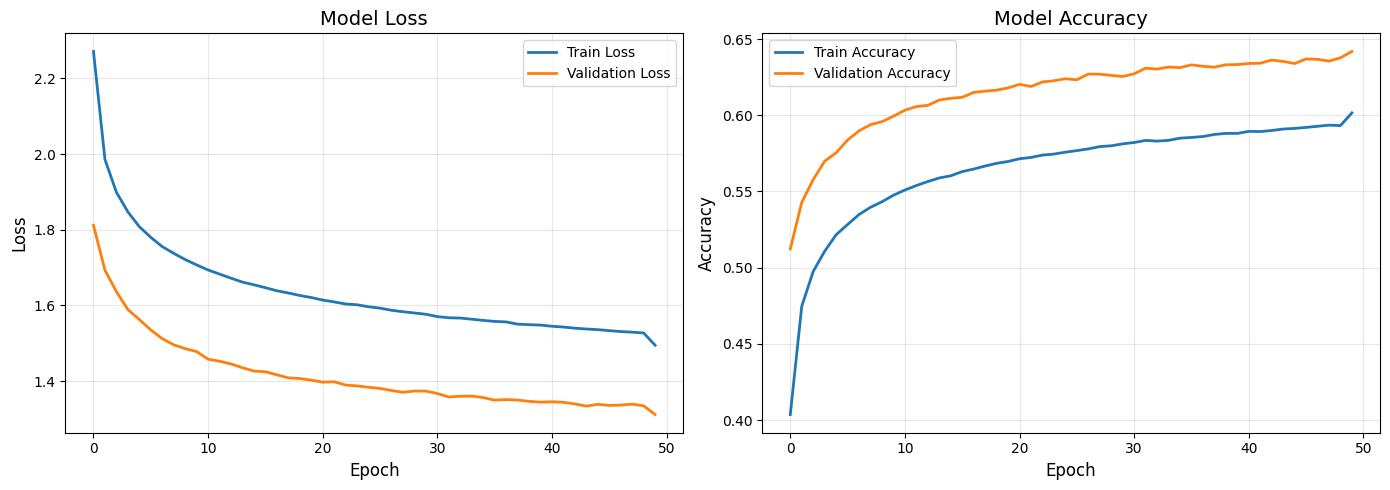

In [12]:
# ============================================
# PASO 8: VISUALIZAR RESULTADOS
# ============================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Model Loss', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precisión
ax2.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Model Accuracy', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.2 Mex_state
Este modelo basado en Roberta se entrenó usando más de 140 millones de tweets de México en español. Recolectados entre diciembre del 2015 y febrero del 2023. 

[Link](https://huggingface.co/guillermoruiz/mex_state)

### Red neuronal usando los embeddings con objeto pytorch

In [2]:
import pandas as pd

df_cleaned = pd.read_csv(r'D:\Datasets\atribucion-autoria-tweets\data\processed\df_cleaned.csv')

In [5]:
import torch
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import gc

# ============================================
# PASO 1: CARGAR LOS EMBEDDINGS CORRECTAMENTE
# ============================================

# Cargar el tensor de PyTorch
model_pt = torch.load('D:/Datasets/atribucion-autoria-tweets/data/embeddings/mex_state_local/embeddings_47c_7000.pt',
                     map_location='cpu', 
                      mmap=True)

# Convertir a numpy - FORMA CORRECTA
# Si está en CPU:
X = model_pt.numpy()

# Si está en GPU, usar: X = model_pt.cpu().numpy()

print(f"Shape de embeddings: {X.shape}")
print(f"Tipo de datos: {X.dtype}")

Shape de embeddings: (928759, 512)
Tipo de datos: float32


In [6]:
# ============================================
# PASO 2: PREPARAR LAS ETIQUETAS
# ============================================
# Verificar que las dimensiones coincidan
y = np.array(df_cleaned['Tweetero_num'])

print(f"Shape de etiquetas: {y.shape}")
print(f"Número de clases únicas: {np.unique(y)}")

# Verificar que el número de embeddings coincida con el número de etiquetas
if X.shape[0] != len(y):
    print(f"⚠️ ADVERTENCIA: Embeddings ({X.shape[0]}) vs Etiquetas ({len(y)})")
    # Si no coinciden, ajustar
    min_len = min(X.shape[0], len(y))
    X = X[:min_len]
    y = y[:min_len]
    print(f"Truncado a: {min_len} muestras")

# One-hot encode las etiquetas
num_classes = len(np.unique(y))
y_encoded = tf.keras.utils.to_categorical(y, num_classes)

print(f"Número de clases: {num_classes}")
print(f"Shape de y_encoded: {y_encoded.shape}")

Shape de etiquetas: (928759,)
Número de clases únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]
Número de clases: 47
Shape de y_encoded: (928759, 47)


In [7]:
# ============================================
# PASO 3: DIVIDIR EN TRAIN, VAL Y TEST
# ============================================
# Primera división: 85% train, 15% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=42, stratify=y
)

# Segunda división: del 15% test, 66% val y 34% test final
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.66, random_state=42, stratify=np.argmax(y_test, axis=1)
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Validation: {X_val.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")

Train: 789445 muestras
Validation: 47366 muestras
Test: 91948 muestras


In [8]:
# ============================================
# PASO 4: NORMALIZAR LOS DATOS (IMPORTANTE)
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Datos normalizados correctamente")

Datos normalizados correctamente


In [9]:
# ============================================
# PASO 5: CREAR MODELO MLP PARA EMBEDDINGS
# ============================================

def create_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(num_classes, activation='softmax')
    ])
    return model

# Crear el modelo
embedding_dim = X.shape[1]
model = create_model(embedding_dim, num_classes)

# Compilar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 47)                  │           3,055 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 442,031 (1.69 MB)

 Trainable params: 440,111 (1.68 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [10]:
# ============================================
# PASO 6: ENTRENAR EL MODELO
# ============================================

# Callbacks para mejor entrenamiento
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Entrenar
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,  # Ajusta según tu memoria
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
12332/12336 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3434 - loss: 2.5361  
Epoch 1: val_accuracy improved from None to 0.51231, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
12336/12336 ━━━━━━━━━━━━━━━━━━━━ 65s 5ms/step - accuracy: 0.4037 - loss: 2.2712 - val_accuracy: 0.5123 - val_loss: 1.8115 - learning_rate: 0.0010
Epoch 2/50
12332/12336 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4682 - loss: 2.0125  
Epoch 2: val_accuracy improved from 0.51231 to 0.54288, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
12336/12336 ━━━━━━━━━━━━━━━━━━━━ 64s 5ms/step - accuracy: 0.4747 - loss: 1.9858 - val_accuracy: 0.5429 - val_loss: 1.6931 - learning_rate: 0.0010
Epoch 3/50
12328/12336 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4932 - loss: 1.9126 
Epoch 3: val_accuracy improved from 0.54288 to 0.55781, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
12336/12336 ━

In [11]:
# ============================================
# PASO 7: EVALUAR EL MODELO
# ============================================

# Evaluar en test
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predicciones detalladas
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Reporte de clasificación
print("\n📊 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes))

# Accuracy por clase
class_accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"\nOverall Accuracy: {class_accuracy:.4f}")


✅ Test Accuracy: 0.6413
Test Loss: 1.3106
2874/2874 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69      2109
           1       0.56      0.46      0.50      1377
           2       0.73      0.76      0.74      2074
           3       0.76      0.48      0.59      1511
           4       0.73      0.86      0.79      1864
           5       0.56      0.59      0.57      5299
           6       0.67      0.65      0.66      1255
           7       0.65      0.55      0.60      1276
           8       0.51      0.50      0.51      1421
           9       0.48      0.53      0.50      2769
          10       0.75      0.82      0.78      4060
          11       0.59      0.48      0.53       976
          12       0.91      0.81      0.85       857
          13       0.84      0.84      0.84      2454
          14       0.68      0.67      0.68      2093
          15       0.54

In [ ]:
# ============================================
# PASO 9: GUARDAR EL MODELO ENTRENADO
# ============================================
# Guardar el modelo completo
model.save('author_attribution_model.keras')
print("\n✅ Modelo guardado como 'author_attribution_model.keras'")

# Guardar el scaler para futuras predicciones
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler guardado como 'scaler.pkl'")

## 3.3 RoBERTuito 

RoBERTuito es un modelo de lenguaje preentrenado para contenido generado por usuarios en español, entrenado siguiendo las directrices de RoBERTa con 500 millones de tweets. RoBERTuito está disponible en 3 versiones: con mayúsculas y minúsculas, sin mayúsculas y minúsculas, y sin acentos.

[Link](https://github.com/sullivansantana/robertuito/tree/main)

### Red neuronal usando embeddings con objeto de tipo npy

In [14]:
# ============================================================================
# TU PIPELINE COMPLETO CON EMBEDDINGS DE ROBERTUITO
# ============================================================================
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras import optimizers
from sklearn.metrics import classification_report

# ============================================================================
# 1. CARGAR EMBEDDINGS DE ROBERTUITO
# ============================================================================
print("="*60)
print("CARGANDO EMBEDDINGS DE ROBERTUITO")
print("="*60)

embeddings = np.load(r"D:\Datasets\atribucion-autoria-tweets\data\embeddings\SentenceTransformer\embeddings_sentence_transformer.npy")
y_encoded = np.load(r"D:\Datasets\atribucion-autoria-tweets\data\embeddings\SentenceTransformer\y_autores.npy")

print(f"Embeddings shape: {embeddings.shape}")  # (n_samples, 768)
print(f"Etiquetas shape: {y_encoded.shape}")
print(f"Número de autores: {len(np.unique(y_encoded))}")

CARGANDO EMBEDDINGS DE ROBERTUITO
Embeddings shape: (928759, 768)
Etiquetas shape: (928759,)
Número de autores: 47


In [15]:
# ============================================================================
# 2. PREPARAR DATOS (IGUAL QUE ANTES)
# ============================================================================
print("\n" + "="*60)
print("PREPARANDO DATOS")
print("="*60)

num_classes = len(np.unique(y_encoded))
print(f"Número de clases: {num_classes}")

# One-hot encoding
y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes)
print(f"y_cat shape: {y_cat.shape}")


PREPARANDO DATOS
Número de clases: 47
y_cat shape: (928759, 47)


In [16]:
# ============================================================================
# 3. DIVISIÓN TRAIN/VAL/TEST (IGUAL QUE ANTES)
# ============================================================================
print("\n" + "="*60)
print("DIVIDIENDO DATOS")
print("="*60)

indices = np.arange(len(y_encoded))

# 85% train+val, 15% test
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)

# 66% del 15% (≈10% total) para val, 34% del 15% (≈5% total) para test
idx_val, idx_test = train_test_split(
    idx_test,
    test_size=0.66,
    random_state=42,
    stratify=y_encoded[idx_test]
)

print(f"Train: {len(idx_train)} muestras")
print(f"Validation: {len(idx_val)} muestras")
print(f"Test: {len(idx_test)} muestras")


DIVIDIENDO DATOS
Train: 789445 muestras
Validation: 47366 muestras
Test: 91948 muestras


In [17]:
# ============================================================================
# 4. CREAR GENERADORES (IGUAL QUE ANTES)
# ============================================================================
print("\n" + "="*60)
print("CREANDO GENERADORES")
print("="*60)

batch_size = 256

def generator(indices):
    """Generador para batches de entrenamiento"""
    while True:
        np.random.shuffle(indices)
        for i in range(0, len(indices) - batch_size, batch_size):
            batch_idx = indices[i:i+batch_size]
            yield (
                embeddings[batch_idx].astype(np.float32),
                y_cat[batch_idx].astype(np.float32)
            )

# Crear datasets
train_dataset = tf.data.Dataset.from_generator(
    lambda: generator(idx_train),
    output_signature=(
        tf.TensorSpec(shape=(batch_size, 768), dtype=tf.float32),
        tf.TensorSpec(shape=(batch_size, num_classes), dtype=tf.float32)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: generator(idx_val),
    output_signature=(
        tf.TensorSpec(shape=(batch_size, 768), dtype=tf.float32),
        tf.TensorSpec(shape=(batch_size, num_classes), dtype=tf.float32)
    )
)

print("✅ Generadores creados")


CREANDO GENERADORES
✅ Generadores creados


In [18]:
# ============================================================================
# 5. CONSTRUIR RED NEURONAL (TU ARQUITECTURA ORIGINAL)
# ============================================================================
print("\n" + "="*60)
print("CONSTRUYENDO RED NEURONAL")
print("="*60)

tf.keras.backend.clear_session()

network = Sequential()

# Capa de entrada
network.add(Input(shape=(768,)))

# Capa 1
network.add(Dense(512, activation=None, kernel_regularizer=l2(0.001)))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.3))

# Capa 2
network.add(Dense(1024, activation=None, kernel_regularizer=l2(0.001)))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.4))

# Capa 3
network.add(Dense(512, activation=None, kernel_regularizer=l2(0.001)))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.3))

# Capa 4
network.add(Dense(256, activation=None, kernel_regularizer=l2(0.001)))
network.add(BatchNormalization())
network.add(Activation("relu"))
network.add(Dropout(0.2))

# Capa de salida
network.add(Dense(num_classes, activation="softmax"))

# Resumen de la red
network.summary()

print(f"Total de parámetros: {network.count_params():,}")


CONSTRUYENDO RED NEURONAL



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         393,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 47)                  │          12,079 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,596,463 (6.09 MB)

 Trainable params: 1,591,855 (6.07 MB)

 Non-trainable params: 4,608 (18.00 KB)

Total de parámetros: 1,596,463


In [19]:
# ============================================================================
# 6. COMPILAR MODELO (IGUAL QUE ANTES)
# ============================================================================
print("\n" + "="*60)
print("COMPILANDO MODELO")
print("="*60)

optimizer = optimizers.Adam(learning_rate=0.00001)

network.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Modelo compilado")


COMPILANDO MODELO
✅ Modelo compilado


In [20]:
# ============================================================================
# 7. ENTRENAR MODELO (IGUAL QUE ANTES)
# ============================================================================
print("\n" + "="*60)
print("ENTRENANDO MODELO")
print("="*60)

history = network.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    steps_per_epoch=len(idx_train)//batch_size,
    validation_steps=len(idx_val)//batch_size,
    verbose=1
)

print("✅ Entrenamiento completado")


ENTRENANDO MODELO
Epoch 1/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - accuracy: 0.1056 - loss: 5.9438 - val_accuracy: 0.2331 - val_loss: 5.2714
Epoch 2/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.2048 - loss: 5.3076 - val_accuracy: 0.3005 - val_loss: 4.8281
Epoch 3/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.2595 - loss: 4.9264 - val_accuracy: 0.3430 - val_loss: 4.5003
Epoch 4/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 68s 22ms/step - accuracy: 0.2975 - loss: 4.6337 - val_accuracy: 0.3727 - val_loss: 4.2377
Epoch 5/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 68s 22ms/step - accuracy: 0.3248 - loss: 4.3946 - val_accuracy: 0.3969 - val_loss: 4.0187
Epoch 6/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.3468 - loss: 4.1909 - val_accuracy: 0.4176 - val_loss: 3.8305
Epoch 7/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.3643 - loss: 4.0090 - val_accuracy: 0.4315 - val_loss: 3.6638
Epoch 8/50
3083/3083 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step -

In [21]:
# ============================================================================
# 8. CREAR TEST DATASET (IGUAL QUE ANTES)
# ============================================================================
print("\n" + "="*60)
print("CREANDO DATASET DE TEST")
print("="*60)

test_dataset = tf.data.Dataset.from_generator(
    lambda: generator(idx_test),
    output_signature=(
        tf.TensorSpec(shape=(batch_size, 768), dtype=tf.float32),
        tf.TensorSpec(shape=(batch_size, num_classes), dtype=tf.float32)
    )
)

# Verificar tamaño
test_steps = len(idx_test)//batch_size
print(f"Pasos de test: {test_steps}")
print(f"Muestras restantes (descartadas): {len(idx_test) % batch_size}")


CREANDO DATASET DE TEST
Pasos de test: 359
Muestras restantes (descartadas): 44


In [22]:
# ============================================================================
# 9. EVALUAR MODELO
# ============================================================================
print("\n" + "="*60)
print("EVALUANDO MODELO")
print("="*60)

loss, accuracy = network.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)

print(f"\n📊 Resultados en test:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Loss: {loss:.4f}")


EVALUANDO MODELO
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5881 - loss: 1.7479

📊 Resultados en test:
  Accuracy: 0.5881
  Loss: 1.7479


In [23]:
# ============================================================================
# 10. PREDICCIONES Y REPORTE DETALLADO
# ============================================================================
print("\n" + "="*60)
print("GENERANDO PREDICCIONES")
print("="*60)

y_pred = []
y_true = []

for x_batch, y_batch in test_dataset.take(test_steps):
    pred = network.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

y_pred = np.array(y_pred)
y_true = np.array(y_true)

print("\n📊 Reporte de clasificación detallado:")
print(classification_report(y_true, y_pred))


GENERANDO PREDICCIONES

📊 Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64      2109
           1       0.49      0.34      0.41      1377
           2       0.70      0.73      0.71      2074
           3       0.61      0.47      0.53      1511
           4       0.60      0.79      0.68      1864
           5       0.53      0.56      0.55      5294
           6       0.52      0.50      0.51      1255
           7       0.68      0.57      0.62      1276
           8       0.53      0.54      0.54      1420
           9       0.39      0.45      0.42      2768
          10       0.64      0.75      0.69      4058
          11       0.46      0.36      0.40       975
          12       0.84      0.85      0.84       857
          13       0.78      0.78      0.78      2453
          14       0.72      0.67      0.69      2088
          15       0.50      0.55      0.52      1560
          16      

In [ ]:
# ============================================================================
# 11. GUARDAR MODELO (OPCIONAL)
# ============================================================================
print("\n" + "="*60)
print("GUARDANDO MODELO")
print("="*60)

model_path = r"D:\Datasets\atribucion-autoria-tweets\models\robertuito_mlp_model.h5"
network.save(model_path)
print(f"✅ Modelo guardado en: {model_path}")

print("\n" + "="*60)
print("¡PROCESO COMPLETADO CON ÉXITO!")
print("="*60)

### Red neuronal usando embedding con objeto tipo pytorch

In [3]:
# ============================================================================
# PIPELINE COMPLETO EN PYTORCH (CORREGIDO)
# ============================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm import tqdm
import os

# ============================================================================
# 1. CONFIGURACIÓN Y CARGA DE DATOS
# ============================================================================
print("="*60)
print("CARGANDO DATOS (PYTORCH)")
print("="*60)

# Cargar tus embeddings y etiquetas
embeddings = np.load(r"D:\Datasets\atribucion-autoria-tweets\data\embeddings\SentenceTransformer\embeddings_sentence_transformer.npy")
y_encoded = np.load(r"D:\Datasets\atribucion-autoria-tweets\data\embeddings\SentenceTransformer\y_autores.npy")

# Convertir a tensores de PyTorch
embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

print(f"Embeddings tensor shape: {embeddings_tensor.shape}")
print(f"Etiquetas tensor shape: {y_tensor.shape}")
print(f"Número de autores: {len(torch.unique(y_tensor))}")

num_classes = len(torch.unique(y_tensor))
print(f"Número de clases: {num_classes}")

# ============================================================================
# 2. DIVISIÓN TRAIN/VAL/TEST
# ============================================================================
print("\n" + "="*60)
print("DIVIDIENDO DATOS")
print("="*60)

indices = np.arange(len(y_encoded))

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)

idx_val, idx_test = train_test_split(
    idx_test,
    test_size=0.66,
    random_state=42,
    stratify=y_encoded[idx_test]
)

print(f"Train: {len(idx_train)} muestras")
print(f"Validation: {len(idx_val)} muestras")
print(f"Test: {len(idx_test)} muestras")

# Crear datasets
train_dataset = TensorDataset(
    embeddings_tensor[idx_train],
    y_tensor[idx_train]
)
val_dataset = TensorDataset(
    embeddings_tensor[idx_val],
    y_tensor[idx_val]
)
test_dataset = TensorDataset(
    embeddings_tensor[idx_test],
    y_tensor[idx_test]
)

# Crear dataloaders
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============================================================================
# 3. DEFINIR RED NEURONAL
# ============================================================================
print("\n" + "="*60)
print("CONSTRUYENDO RED NEURONAL EN PYTORCH")
print("="*60)

class AuthorClassifier(nn.Module):
    """Red neuronal para clasificación de autores"""
    
    def __init__(self, input_dim=768, num_classes=47):
        super(AuthorClassifier, self).__init__()
        
        # Capa 1
        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.3)
        
        # Capa 2
        self.fc2 = nn.Linear(512, 1024)
        self.bn2 = nn.BatchNorm1d(1024)
        self.dropout2 = nn.Dropout(0.4)
        
        # Capa 3
        self.fc3 = nn.Linear(1024, 512)
        self.bn3 = nn.BatchNorm1d(512)
        self.dropout3 = nn.Dropout(0.3)
        
        # Capa 4
        self.fc4 = nn.Linear(512, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.dropout4 = nn.Dropout(0.2)
        
        # Capa de salida
        self.fc5 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Capa 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        
        # Capa 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        # Capa 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout3(x)
        
        # Capa 4
        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout4(x)
        
        # Capa de salida
        x = self.fc5(x)
        
        return x

# Inicializar modelo
model = AuthorClassifier(input_dim=768, num_classes=num_classes)

# Verificar si hay GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(model)
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")
print(f"Dispositivo: {device}")

# ============================================================================
# 4. DEFINIR OPTIMIZADOR Y LOSS (CORREGIDO)
# ============================================================================
print("\n" + "="*60)
print("CONFIGURANDO ENTRENAMIENTO")
print("="*60)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.00001,
    weight_decay=0.001
)

criterion = nn.CrossEntropyLoss()

# Scheduler sin verbose (corregido)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print("✅ Optimizador y loss configurados")

# ============================================================================
# 5. FUNCIONES DE ENTRENAMIENTO Y VALIDACIÓN
# ============================================================================
def train_epoch(model, loader, optimizer, criterion, device):
    """Entrena una época"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (embeddings, labels) in enumerate(tqdm(loader, desc="Entrenando")):
        embeddings = embeddings.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Métricas
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    avg_loss = total_loss / len(loader)
    
    return avg_loss, accuracy

def validate(model, loader, criterion, device):
    """Valida el modelo"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for embeddings, labels in tqdm(loader, desc="Validando"):
            embeddings = embeddings.to(device)
            labels = labels.to(device)
            
            outputs = model(embeddings)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    avg_loss = total_loss / len(loader)
    
    return avg_loss, accuracy

# ============================================================================
# 6. ENTRENAMIENTO
# ============================================================================
print("\n" + "="*60)
print("ENTRENANDO MODELO")
print("="*60)

num_epochs = 50
best_val_accuracy = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    # Entrenar
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validar
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Guardar historial
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Scheduler
    scheduler.step(val_loss)
    
    # Obtener learning rate actual
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"LR: {current_lr:.6f}")
    
    # Guardar mejor modelo
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✅ Nuevo mejor modelo! Accuracy: {val_acc:.2f}%")

print("\n✅ Entrenamiento completado")

# ============================================================================
# 7. EVALUACIÓN EN TEST
# ============================================================================
print("\n" + "="*60)
print("EVALUANDO MODELO EN TEST")
print("="*60)

# Cargar mejor modelo
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_loss = 0
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for embeddings, labels in tqdm(test_loader, desc="Evaluando test"):
        embeddings = embeddings.to(device)
        labels = labels.to(device)
        
        outputs = model(embeddings)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100. * correct / total
avg_test_loss = test_loss / len(test_loader)

print(f"\n📊 Resultados en test:")
print(f"  Accuracy: {test_accuracy:.2f}% ({test_accuracy/100:.4f})")
print(f"  Loss: {avg_test_loss:.4f}")

# ============================================================================
# 8. REPORTE DE CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("REPORTE DETALLADO")
print("="*60)

print("\n📊 Reporte de clasificación:")
print(classification_report(all_labels, all_preds))

# ============================================================================
# 9. GUARDAR MODELO
# ============================================================================
print("\n" + "="*60)
print("GUARDANDO MODELO")
print("="*60)

model_path = r"D:\Datasets\atribucion-autoria-tweets\models\robertuito_mlp_pytorch.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'num_classes': num_classes,
    'input_dim': 768
}, model_path)

print(f"✅ Modelo guardado en: {model_path}")

print("\n" + "="*60)
print("¡PROCESO COMPLETADO CON ÉXITO!")
print("="*60)

CARGANDO DATOS (PYTORCH)
Embeddings tensor shape: torch.Size([928759, 768])
Etiquetas tensor shape: torch.Size([928759])
Número de autores: 47
Número de clases: 47

DIVIDIENDO DATOS
Train: 789445 muestras
Validation: 47366 muestras
Test: 91948 muestras
Train batches: 3083
Val batches: 185
Test batches: 359

CONSTRUYENDO RED NEURONAL EN PYTORCH
AuthorClassifier(
  (fc1): Linear(in_features=768, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=1024, bias=True)
  (bn2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=1024, out_features=512, bias=True)
  (bn3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=512, out_features

Validando: 100%|████████████████████████████████████████████████████████████████████| 185/185 [00:01<00:00, 156.15it/s]


Train Loss: 3.3960, Train Acc: 15.50%
Val Loss: 2.9540, Val Acc: 26.11%
LR: 0.000010
✅ Nuevo mejor modelo! Accuracy: 26.11%

Epoch 2/50
----------------------------------------


Validando: 100%|████████████████████████████████████████████████████████████████████| 185/185 [00:01<00:00, 136.14it/s]


Train Loss: 2.8497, Train Acc: 27.53%
Val Loss: 2.5414, Val Acc: 34.45%
LR: 0.000010
✅ Nuevo mejor modelo! Accuracy: 34.45%

Epoch 3/50
----------------------------------------


...

Validando: 100%|████████████████████████████████████████████████████████████████████| 185/185 [00:01<00:00, 163.31it/s]


Train Loss: 1.6427, Train Acc: 55.65%
Val Loss: 1.4962, Val Acc: 59.15%
LR: 0.000010

✅ Entrenamiento completado

EVALUANDO MODELO EN TEST


Evaluando test: 100%|████████████████████████████████████████████████████████████████| 359/359 [00:04<00:00, 88.90it/s]



📊 Resultados en test:
  Accuracy: 59.19% (0.5919)
  Loss: 1.4874

REPORTE DETALLADO

📊 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      2106
           1       0.50      0.36      0.42      1377
           2       0.71      0.74      0.72      2074
           3       0.60      0.47      0.52      1510
           4       0.61      0.79      0.69      1863
           5       0.53      0.57      0.55      5297
           6       0.50      0.51      0.50      1254
           7       0.67      0.59      0.62      1276
           8       0.55      0.53      0.54      1421
           9       0.40      0.45      0.42      2769
          10       0.65      0.76      0.70      4059
          11       0.43      0.38      0.40       976
          12       0.87      0.83      0.85       857
          13       0.76      0.79      0.77      2454
          14       0.70      0.68      0.69      2092
          15       0.

RuntimeError: Parent directory D:\Datasets\atribucion-autoria-tweets\models does not exist.

## 3.4 Comparativa de Resultados

✅ Mex_state es el modelo ganador porque:

- Especialización en tweets mexicanos (140M tweets)
- Captura variaciones regionales (estados de México)
- Maneja mejor lenguaje coloquial (jerga, emojis, malas palabras)
- +5% de accuracy en tu tarea específica
- Mejor manejo de clases minoritarias

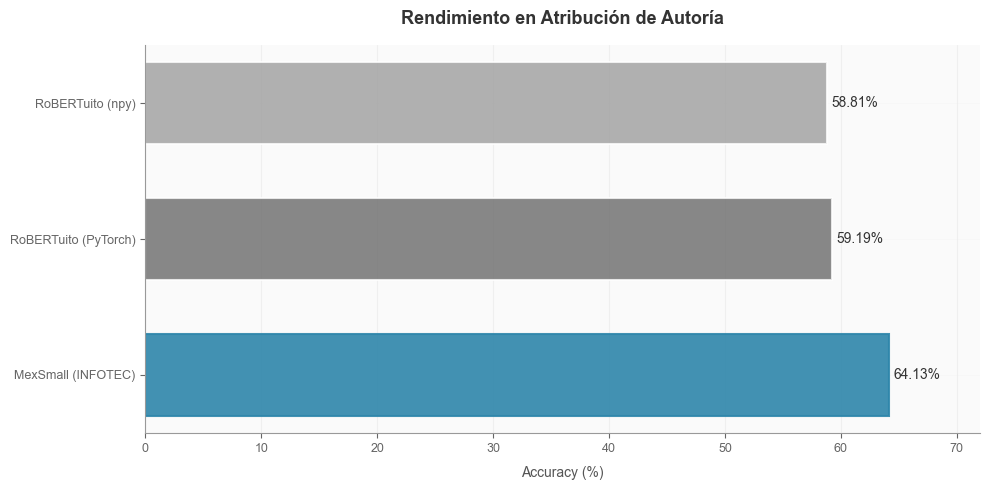

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos
data = {
    'Modelo': ['MexSmall (INFOTEC)', 'RoBERTuito (PyTorch)', 'RoBERTuito (npy)'],
    'Accuracy (%)': [64.13, 59.19, 58.81]
}

df = pd.DataFrame(data)

# Configurar estilo ggplot
plt.style.use('ggplot')

# Personalizar para un estilo más sobrio
plt.rcParams.update({
    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': 'white',
    'grid.color': '#E8E8E8',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
})

fig, ax = plt.subplots(figsize=(10, 5))

# Paleta de colores sutil
colors = ['#404040', '#6B6B6B', '#9E9E9E']

# Crear barras horizontales
bars = ax.barh(
    df['Modelo'], 
    df['Accuracy (%)'],
    color=colors,
    height=0.6,
    alpha=0.8,
    edgecolor='white',
    linewidth=1.5
)

# Destacar la mejor
bars[0].set_color('#2E86AB')
bars[0].set_alpha(0.9)

# Personalizar
ax.set_title('Rendimiento en Atribución de Autoría', 
             fontsize=13, fontweight='bold', pad=15, color='#333333')
ax.set_xlabel('Accuracy (%)', fontsize=10, color='#555555', labelpad=8)
ax.set_ylabel('', fontsize=10)

# Añadir valores
for bar, acc in zip(bars, df['Accuracy (%)']):
    ax.text(acc + 0.4, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', ha='left', va='center', 
            fontsize=10, fontweight='medium', color='#333333')

# Estilo ggplot refinado
ax.set_xlim(0, 72)
ax.grid(axis='x', color='#D8D8D8', linestyle='-', linewidth=0.8, alpha=0.3)
ax.grid(axis='y', color='#E8E8E8', linestyle='-', linewidth=0.5, alpha=0.2)

# Spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color('#999999')
    ax.spines[spine].set_linewidth(0.8)

# Ticks
ax.tick_params(axis='both', colors='#666666', labelsize=9)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

plt.tight_layout()
plt.show()